# HDFS Baseline Model Experiment

This notebook trains and evaluates an Isolation Forest baseline model on the HDFS dataset.

**Dataset Source:** LogHub - HDFS_v1  
**Citation:** Wei Xu et al. (SOSP 2009), Jieming Zhu et al. (ISSRE 2023)

### Experiment Overview

- **Dataset**: HDFS (LogHub preprocessed)
- **Model**: Isolation Forest (unsupervised anomaly detection)
- **Evaluation**: Accuracy, Precision, Recall, F1, AUC
- **Data Split**: 60% train, 20% validation, 20% test

### 1. Setup and Imports

In [7]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))


from src.models.baselines import IsolationForestBaseline, evaluate_model, print_metrics
from src.utils.data_loader import load_loghub, create_train_val_test_split
from src.utils.visualizer import UniversalAnomalyVisualizer

### 2. Load and Prepare Data

In [8]:
# Define paths
DATA_DIR = '../../data/hdfs/preprocessed'

In [9]:
# Load HDFS data
print("Loading HDFS data...")
x_data, y_data, vocab = load_loghub(DATA_DIR)

# Split into train/val/test
print("\nSplitting data...")
splits = create_train_val_test_split(
    x_data, y_data, 
    train_ratio=0.6, 
    val_ratio=0.2, 
    test_ratio=0.2
)

X_train, y_train = splits['train']
X_val, y_val = splits['val']
X_test, y_test = splits['test']

print(f"\n✓ Data loaded and split successfully!")
print(f"  Vocabulary size: {len(vocab) if vocab else 'N/A'}")

INFO:src.utils.data_loader:Loading data from LogHub preprocessing: ../../data/hdfs/preprocessed


Loading HDFS data...


INFO:src.utils.data_loader:Loaded data:
INFO:src.utils.data_loader:  - Sequences: (575061,)
INFO:src.utils.data_loader:  - Labels: (575061,)
INFO:src.utils.data_loader:  - Normal: 558223, Anomaly: 16838
INFO:src.utils.data_loader:  - Loaded vocabulary: 29 events
INFO:src.utils.data_loader:Splitting data: train=0.6, val=0.2, test=0.2
INFO:src.utils.data_loader:Split complete:
INFO:src.utils.data_loader:  - Train: 345036 samples (10103 anomalies)
INFO:src.utils.data_loader:  - Val:   115012 samples (3367 anomalies)
INFO:src.utils.data_loader:  - Test:  115013 samples (3368 anomalies)



Splitting data...

✓ Data loaded and split successfully!
  Vocabulary size: 29


In [10]:
# Load occurrence matrix (Isolation Forest needs feature vectors)
import pandas as pd

print("Loading occurrence matrix...")
occurrence_matrix_path = f'{DATA_DIR}/Event_occurrence_matrix.csv'
occurrence_df = pd.read_csv(occurrence_matrix_path)

# Drop non-numeric columns (BlockId, Label, Type)
# Keep only event count columns (E1-E29)
columns_to_drop = ['BlockId', 'Label', 'Type']
X_features = occurrence_df.drop(columns=columns_to_drop, errors='ignore').values

print(f"✓ Occurrence matrix loaded: {X_features.shape}")
print(f"  Features: {X_features.shape[1]} event types")
print(f"  Samples: {X_features.shape[0]} sequences")

Loading occurrence matrix...
✓ Occurrence matrix loaded: (575061, 29)
  Features: 29 event types
  Samples: 575061 sequences


In [11]:
# Split occurrence matrix using the same function and parameters
import numpy as np

print("\nSplitting occurrence matrix...")
occurrence_splits = create_train_val_test_split(
    X_features, y_data,
    train_ratio=0.6,
    val_ratio=0.2,
    test_ratio=0.2
)

X_train_occ, y_train_check = occurrence_splits['train']
X_val_occ, y_val_check = occurrence_splits['val']
X_test_occ, y_test_check = occurrence_splits['test']

# Verify labels match (they should since we used same random_state)
assert np.array_equal(y_train, y_train_check), "Train labels mismatch!"
assert np.array_equal(y_val, y_val_check), "Val labels mismatch!"
assert np.array_equal(y_test, y_test_check), "Test labels mismatch!"
print("✓ Occurrence matrix splits aligned with sequence splits!")

INFO:src.utils.data_loader:Splitting data: train=0.6, val=0.2, test=0.2



Splitting occurrence matrix...


INFO:src.utils.data_loader:Split complete:
INFO:src.utils.data_loader:  - Train: 345036 samples (10103 anomalies)
INFO:src.utils.data_loader:  - Val:   115012 samples (3367 anomalies)
INFO:src.utils.data_loader:  - Test:  115013 samples (3368 anomalies)


✓ Occurrence matrix splits aligned with sequence splits!


### 3. Train Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm. We'll train it on the training set (without using labels) and evaluate on test set.

In [12]:
# Calculate contamination (proportion of anomalies in training set)
train_contamination = (y_train == 1).sum() / len(y_train)
print(f"Training set anomaly rate: {train_contamination:.4f} ({(y_train == 1).sum()} / {len(y_train)})")

# Initialize Isolation Forest
# Use contamination slightly higher than actual rate to be more sensitive
model = IsolationForestBaseline(
    contamination=train_contamination,  
    n_estimators=100,
    random_state=42
)

# Train (unsupervised - labels are not used)
print("\nTraining Isolation Forest...")
model.fit(X_train_occ)  # y_train is ignored in unsupervised learning

print("✓ Training complete!")

INFO:src.models.baselines:Isolation Forest initialized: n_estimators=100, contamination=0.029281002562051496
INFO:src.models.baselines:Training Isolation Forest on 345036 samples with 29 features


Training set anomaly rate: 0.0293 (10103 / 345036)

Training Isolation Forest...


INFO:src.models.baselines:Isolation Forest training complete


✓ Training complete!


## 4. Evaluate on Test Set

In [13]:
# Predict on test set
print("Evaluating on test set...")
y_pred = model.predict(X_test_occ)
y_proba = model.predict_proba(X_test_occ)

# Calculate metrics
metrics = evaluate_model(y_test, y_pred, y_proba)

# Print results
print_metrics(metrics, model_name="Isolation Forest (HDFS)")

Evaluating on test set...

Isolation Forest (HDFS) Performance
Accuracy:  0.9486
Precision: 0.0310
Recall:    0.0249
F1 Score:  0.0277
AUC:       0.4968

Confusion Matrix:
  TN: 109023  FP:   2622
  FN:   3284  TP:     84



## 5. Visualization

✓ Saved: ../../figures/baseline/isolation_forest/confusion_matrix.png


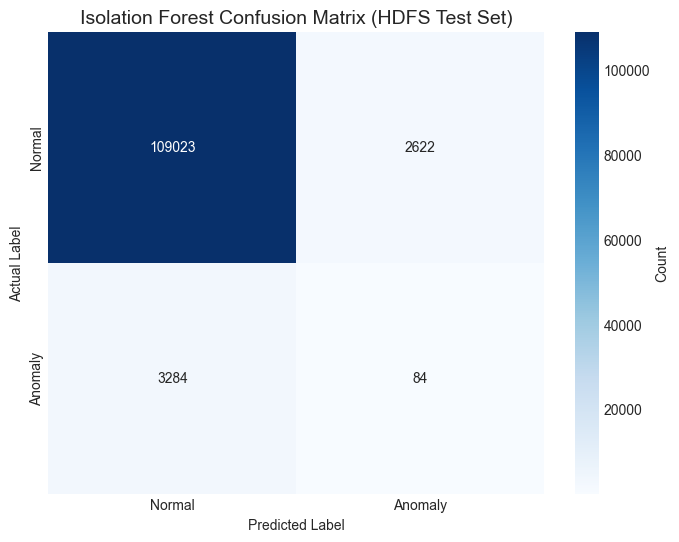

✓ Saved: ../../figures/baseline/isolation_forest/anomaly_score_distribution.png


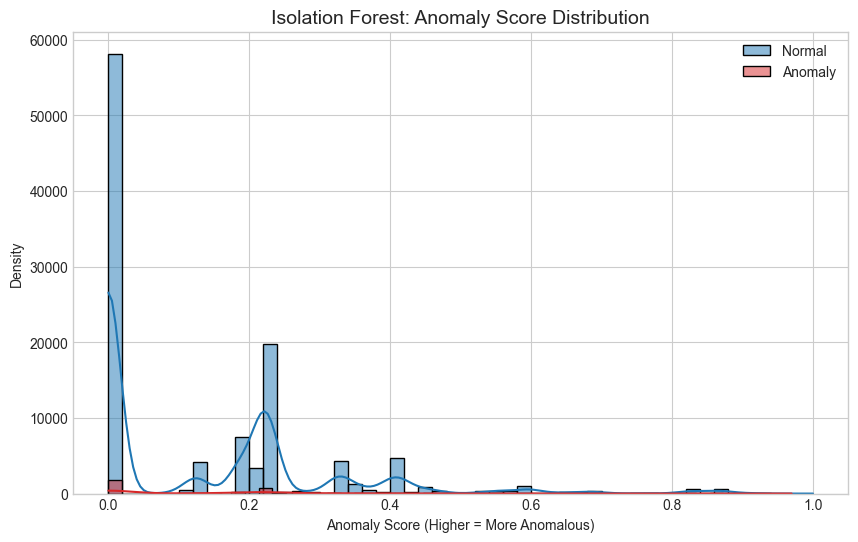

✓ Saved: ../../figures/baseline/isolation_forest/roc_curve.png


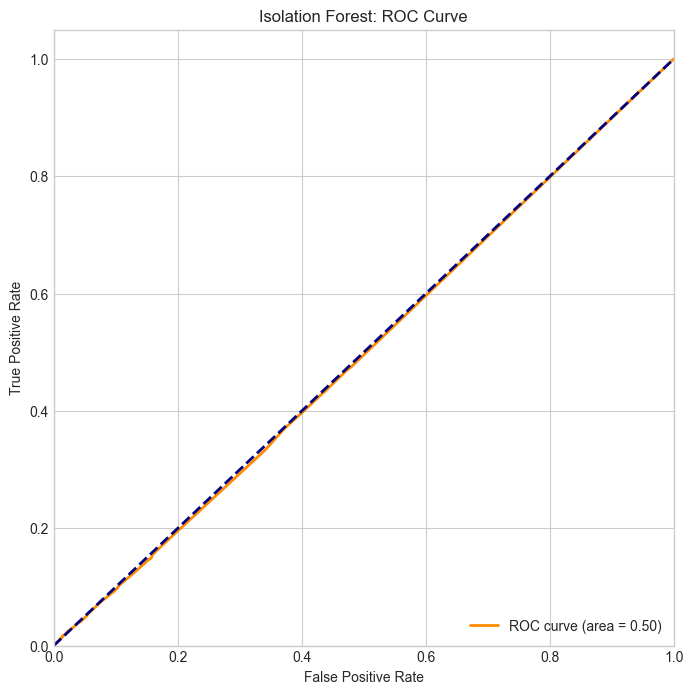

✓ Saved: ../../figures/baseline/isolation_forest/precision_recall_curve.png


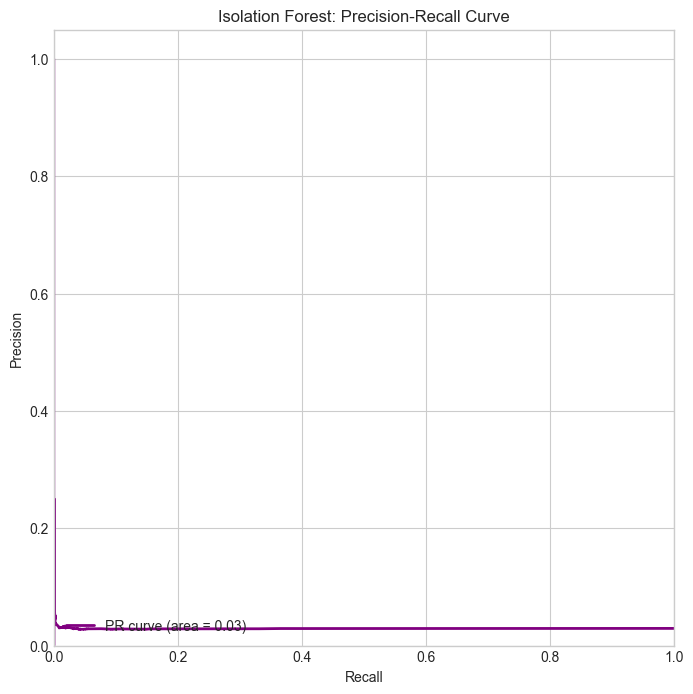


✓ All visualizations generated and saved using UniversalAnomalyVisualizer


In [14]:
# Initialize visualizer with save directory
viz = UniversalAnomalyVisualizer(model_name="Isolation Forest", save_dir="../../figures/baseline/isolation_forest")

# Plot 1: Confusion Matrix
viz.plot_confusion_matrix(y_test, y_pred, title_suffix="(HDFS Test Set)")

# Plot 2: Anomaly Score Distribution
viz.plot_anomaly_score_distribution(y_test, y_proba, bins=50)

# Plot 3: ROC Curve
viz.plot_roc_curve(y_test, y_proba)

# Plot 4: Precision-Recall Curve
viz.plot_precision_recall_curve(y_test, y_proba)

print("\n✓ All visualizations generated and saved using UniversalAnomalyVisualizer")

In [16]:
# Save results to file
results = {
    'dataset': 'HDFS',
    'model': 'Isolation Forest',
    'n_estimators': 100,
    'contamination': float(train_contamination),
    'train_size': len(y_train),
    'test_size': len(y_test),
    'metrics': metrics
}

import json
with open('../../results/hdfs_isolation_forest_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Results saved to results/hdfs_isolation_forest_results.json")

# Display summary table
print("\n" + "=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"Dataset:         HDFS")
print(f"Model:           Isolation Forest")
print(f"Train samples:   {len(y_train):,}")
print(f"Test samples:    {len(y_test):,}")
print(f"Features:        {X_train_occ.shape[1]}")
print(f"Contamination:   {train_contamination:.4f}")
print(f"\nTest Performance:")
print(f"  Accuracy:      {metrics['accuracy']:.4f}")
print(f"  Precision:     {metrics['precision']:.4f}")
print(f"  Recall:        {metrics['recall']:.4f}")
print(f"  F1 Score:      {metrics['f1']:.4f}")
print(f"  AUC:           {metrics['auc']:.4f}")
print("=" * 60)

✓ Results saved to results/hdfs_isolation_forest_results.json

EXPERIMENT SUMMARY
Dataset:         HDFS
Model:           Isolation Forest
Train samples:   345,036
Test samples:    115,013
Features:        29
Contamination:   0.0293

Test Performance:
  Accuracy:      0.9486
  Precision:     0.0310
  Recall:        0.0249
  F1 Score:      0.0277
  AUC:           0.4968
